## **BƯỚC 1: CÀI ĐẶT THƯ VIỆN**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk


## **BƯỚC 2: THU THẬP DỮ LIỆU**

In [18]:
!pip install vnstock -U

# Dữ liệu FPT từ ngày 01/01/2018 đến ngày 31/12/2025, được lấy từ thư viện vnstock
from vnstock import Market
mkt = Market()
data = mkt.equity("FPT").ohlcv(start="2018-01-01", end="2025-12-31", interval='1D', count=10000)
data['time'] = pd.to_datetime(data['time']).dt.tz_localize(None)
data.set_index('time', inplace=True)


## **XỬ LÝ DỮ LIỆU**


In [19]:
# Kiểm tra dữ liệu có trùng lặp không
print("Số lượng dữ liệu trùng lặp:", data.duplicated().sum())
# Kiểm tra dữ liệu có giá trị thiếu không 
print("Số lượng giá trị thiếu:\n", data.isna().sum())


Số lượng dữ liệu trùng lặp: 0
Số lượng giá trị thiếu:
 open      0
high      0
low       0
close     0
volume    0
dtype: int64


##  **BƯỚC 3: FEATURE ENGINEERING**

In [20]:
def build_features(data: pd.DataFrame):

    fm = pd.DataFrame(index=data.index)
    close = data['close']
    high = data['high']
    low = data['low']
    open_ = data['open']
 
    # 0. TARGET - Lợi nhuận kỳ vọng 5 phiên tới
    target = close.pct_change(5).shift(-5)
    fm['target_reg'] = target
    fm['target'] = (target > 0.0015).astype(int)  # Ngưỡng sinh lời bù đắp phí giao dịch 0.15%
 
    # 1. realized_vol_20d (Độ biến động lịch sử 20 phiên)
    log_ret = np.log(close / close.shift(1))
    fm['realized_vol_20d'] = log_ret.rolling(20).std()
 
    # 2. zscore_20 (Điểm chuẩn hóa Z-score của giá đóng cửa 20 phiên)
    ma20 = close.rolling(20).mean()
    std20 = close.rolling(20).std()
    fm['zscore_20'] = (close - ma20) / (std20 + 1e-9)
 
    # adx_14 & ma20_slope
    high_low   = high - low
    high_close = (high - close.shift()).abs()
    low_close  = (low  - close.shift()).abs()
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
 
    up_move   = high.diff()
    down_move = -low.diff()
    plus_dm  = up_move.where((up_move > down_move) & (up_move > 0), 0.0)
    minus_dm = down_move.where((down_move > up_move) & (down_move > 0), 0.0)
    atr14 = tr.rolling(14).mean()
    plus_di  = 100 * (plus_dm.rolling(14).mean()  / (atr14 + 1e-9))
    minus_di = 100 * (minus_dm.rolling(14).mean() / (atr14 + 1e-9))
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-9)
    adx_14 = dx.rolling(14).mean()
    ma20_slope = (ma20 - ma20.shift(5)) / (ma20.shift(5) + 1e-9)
 
    # 3. trend_strength (Sức mạnh xu hướng, kết hợp ADX 14 và độ dốc MA20)
    fm['trend_strength']  = adx_14 * ma20_slope.abs()
 
    # 4. gk_vol_20d (Độ biến động Garman-Klass 20 phiên)
    gk_vol = 0.5 * (np.log(high / (low + 1e-9)))**2 - (2 * np.log(2) - 1) * (np.log(close / (open_ + 1e-9)))**2
    fm['gk_vol_20d'] = gk_vol.rolling(20).mean()
 
    # 5. atr_14d (Chỉ số ATR chuẩn hóa theo giá 14 phiên)
    fm['atr_14d'] = atr14 / close
 
    # 6. vol_ratio_sl (Tỷ lệ biến động ngắn hạn / dài hạn)
    fm['vol_ratio_sl'] = log_ret.rolling(5).std() / (log_ret.rolling(20).std() + 1e-9)
 
    # 7. ret_20d (Lợi nhuận trung bình kỳ hạn 20 phiên)
    fm['ret_20d'] = close.pct_change(20).add(1).pow(1/20).sub(1)
 
    # 8. ret_5d (Lợi nhuận trung bình kỳ hạn 5 phiên)
    fm['ret_5d'] = close.pct_change(5).add(1).pow(1/5).sub(1)
 
    # 9. ma_dist_20d (Khoảng cách tương đối từ giá đóng cửa tới MA20)
    fm['ma_dist_20d'] = (close - ma20) / ma20
 
    # 10. rsi_14 (Chỉ số sức mạnh tương đối RSI 14)
    delta = close.diff()
    gain = delta.where(delta > 0, 0.0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0.0)).rolling(14).mean()
    fm['rsi_14'] = 100 - (100 / (1 + gain / (loss + 1e-9)))
 
    # 11. dist_52w_high (Khoảng cách tương đối từ giá đóng cửa tới đỉnh 52 tuần)
    high252 = high.rolling(252).max()
    fm['dist_52w_high'] = (close - high252) / (high252 + 1e-9)
 
    # 12. ma_dist_5d (Khoảng cách tương đối từ giá đóng cửa tới MA5)
    ma5 = close.rolling(5).mean()
    fm['ma_dist_5d'] = (close - ma5) / ma5
 
    # 13. bb_percent (Chỉ số phần trăm băng Bollinger %B)
    bb_upper = ma20 + 2 * std20
    bb_lower = ma20 - 2 * std20
    fm['bb_percent'] = (close - bb_lower) / (bb_upper - bb_lower + 1e-9)
 
    # 14. cci_20 (Chỉ số kênh hàng hóa CCI 20)
    typical_price = (high + low + close) / 3
    fm['cci_20'] = (typical_price - typical_price.rolling(20).mean()) / \
                   (0.015 * typical_price.rolling(20).apply(lambda x: np.mean(np.abs(x - x.mean())), raw=True) + 1e-9)
 
    # 15. ma_dist_200d (Khoảng cách tương đối từ giá đóng cửa tới MA200)
    ma200 = close.rolling(200).mean()
    fm['ma_dist_200d'] = (close - ma200) / ma200
 
    # Clean and keep 'target'
    fm = fm.drop(columns=['target_reg'])
    fm = fm.dropna().copy()
 
    return fm
data_model = build_features(data)


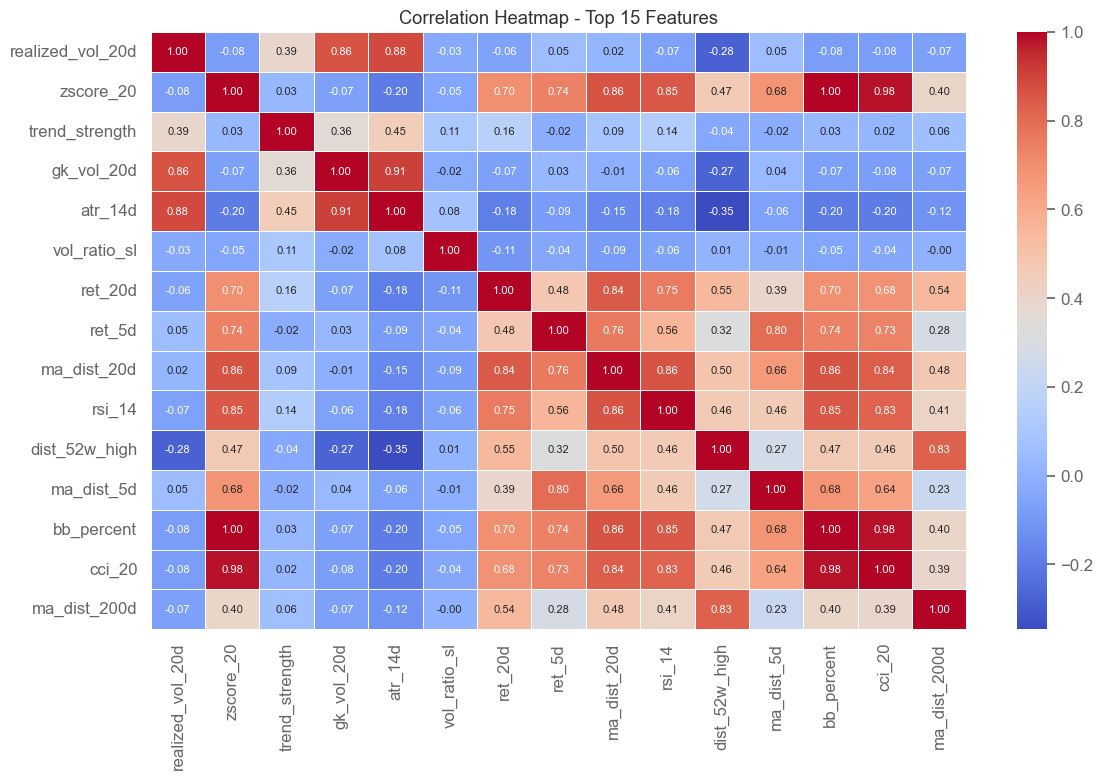

In [21]:
# kiểm tra tương quan giữa các features (hiển thị chi tiết giá trị cho 15 features)
corr_matrix = data_model.drop(columns=['target']).corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    annot_kws={'size': 8}
)

plt.title("Correlation Heatmap - Top 15 Features")
plt.tight_layout()
plt.show()


## **BƯỚC 4: XÂY DỰNG MÔ HÌNH DỰ ĐOÁN**

In [22]:
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score, precision_score
from scipy.stats import spearmanr

# 1. Chuẩn bị dữ liệu huấn luyện
y = data_model['target']
X = data_model.drop(columns=['target'])

print(f"Số lượng features sử dụng: {X.shape[1]}")


# 2. Khởi tạo cấu hình Cross-Validation
tscv = TimeSeriesSplit(n_splits=5, gap=5)  

results = []
y_pred_all = []
y_prob_all = []
y_test_all = []   

# 3. Huấn luyện mô hình
for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    X_train = X.iloc[train_index]
    X_test  = X.iloc[test_index]
    y_train = y.iloc[train_index]
    y_test  = y.iloc[test_index]

    # Khởi tạo mô hình - XGBoost Classifier với các tham số tối ưu 
    model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=4,          # Tối ưu hóa độ sâu
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.5,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss',
        early_stopping_rounds=20
    )
    
    # Chia tập train thành train_sub và val_sub (lấy 10% cuối của tập train làm val)
    val_size = int(len(X_train) * 0.1)
    X_train_sub, X_val = X_train[:-val_size], X_train[-val_size:]
    y_train_sub, y_val = y_train.iloc[:-val_size], y_train.iloc[-val_size:]
    
    model.fit(
        X_train_sub, y_train_sub,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # Dự đoán xác suất tăng giá
    y_prob = model.predict_proba(X_test)[:, 1]
    # Phân loại dựa trên ngưỡng xác suất tối ưu 0.54
    y_pred = (y_prob > 0.54).astype(int)
    
    y_pred = pd.Series(y_pred, index=y_test.index)
    y_prob = pd.Series(y_prob, index=y_test.index)

    # Tính toán các chỉ số đánh giá
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    
    # Tính IC bằng tương quan Spearman giữa xác suất dự đoán (y_prob) và nhãn thực tế (y_test)
    ic = spearmanr(y_prob, y_test)[0]

    # Lưu kết quả từng fold
    results.append({
        'fold': fold,
        'Accuracy': acc,
        'Precision': prec,
        'IC': ic
    })

    y_pred_all.append(y_pred)
    y_prob_all.append(y_prob)
    y_test_all.append(y_test)

y_test_all = pd.concat(y_test_all).sort_index()
y_pred_all = pd.concat(y_pred_all).sort_index()
y_prob_all = pd.concat(y_prob_all).sort_index()

# 4. Tổng hợp
result_df = pd.DataFrame(results)
print(result_df)


Số lượng features sử dụng: 15
   fold  Accuracy  Precision        IC
0     0  0.577320   0.704403  0.080157
1     1  0.549828   0.557851 -0.039853
2     2  0.532646   0.532646  0.029057
3     3  0.556701   0.556701 -0.078776
4     4  0.398625   0.398625  0.088556


--- THỰC THI BACKTEST VỚI CẤU HÌNH ---
Thống kê số lượng lệnh đóng theo lý do: {'SL': 0, 'TP': 153, 'Time': 70}

--- VECTORBT BACKTEST ---
Start                                2020-03-11 07:00:00
End                                  2025-12-31 07:00:00
Period                                1455 days 00:00:00
Start Value                                  100000000.0
End Value                               413818737.130129
Total Return [%]                              313.818737
Benchmark Return [%]                          421.523179
Max Gross Exposure [%]                           98.8218
Total Fees Paid                          21622529.537144
Max Drawdown [%]                               20.710519
Max Drawdown Duration                  339 days 00:00:00
Total Trades                                         126
Total Closed Trades                                  126
Total Open Trades                                      0
Open Trade PnL                                       0.0
Win Ra


Parameter       Value
--------------  ---------
Benchmark       Benchmark
Risk-Free Rate  0.0%
Periods/Year    252
Compounded      Yes
Match Dates     Yes


                           Benchmark    Strategy
-------------------------  -----------  ----------
Start Period               2020-05-11   2020-05-11
End Period                 2025-12-31   2025-12-31
Risk-Free Rate             0.0%         0.0%
Time in Market             95.0%        67.0%

Cumulative Return          393.47%      313.82%
CAGR﹪                     32.88%       28.78%

Sharpe                     1.17         1.54
Prob. Sharpe Ratio         99.73%       99.99%
Smart Sharpe               1.16         1.52
Sortino                    1.78         2.45
Smart Sortino              1.76         2.42
Sortino/√2                 1.26         1.73
Smart Sortino/√2           1.24         1.71
Omega                      1.24         1.41

Max Drawdown               -34.63%      -20.71%
Max DD Date                2025-10-20   20

None

,Start,Valley,End,Days,Max Drawdown,99% Max Drawdown
1,2022-04-19,2023-04-28,2023-08-23,492,-20.710519,-19.872754
2,2023-09-07,2023-10-31,2024-01-31,147,-14.663430,-12.455917
3,2024-07-09,2024-08-05,2024-10-09,93,-12.985501,-11.586655
4,2020-06-09,2020-07-27,2020-10-15,129,-10.570423,-9.458382
5,2025-01-24,2025-02-25,2025-12-31,342,-7.602786,-7.085179


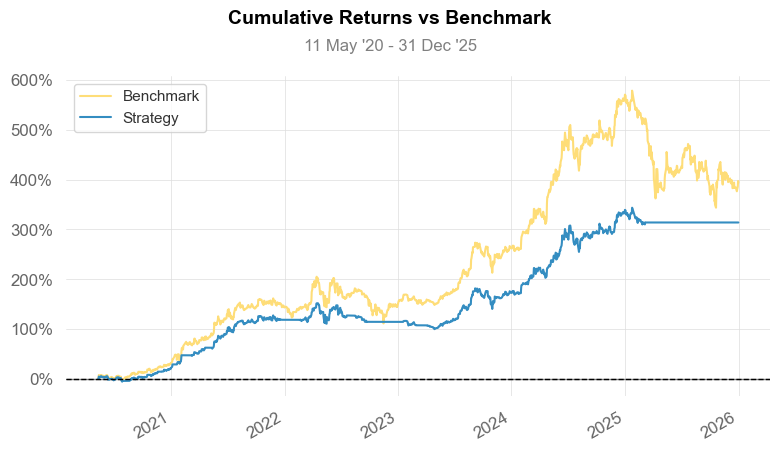

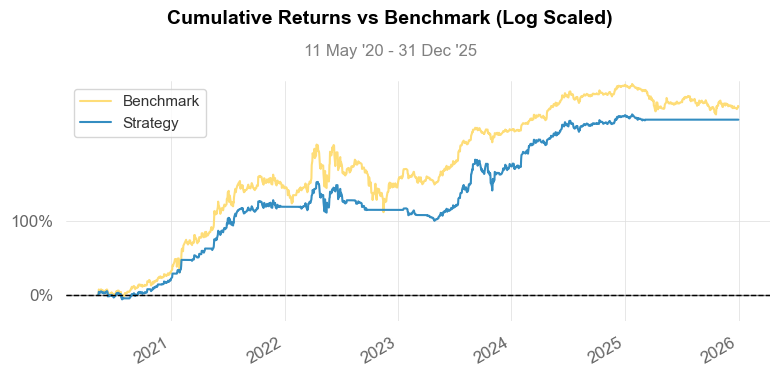

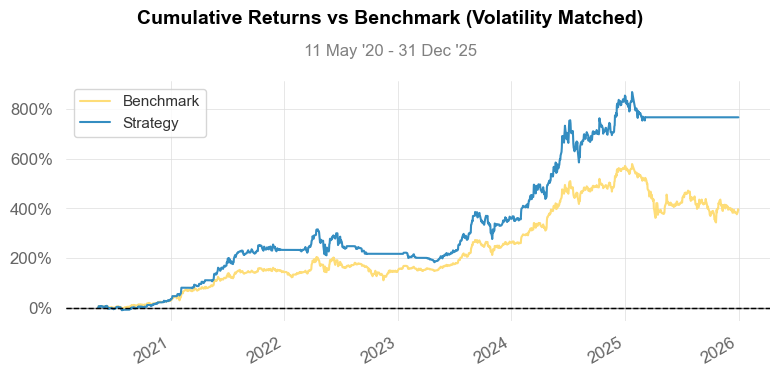

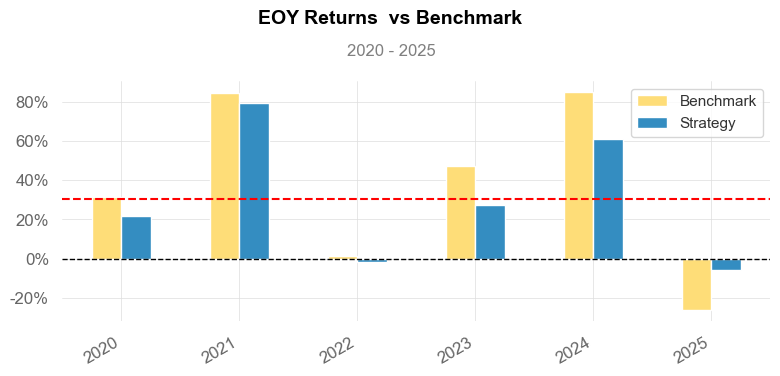

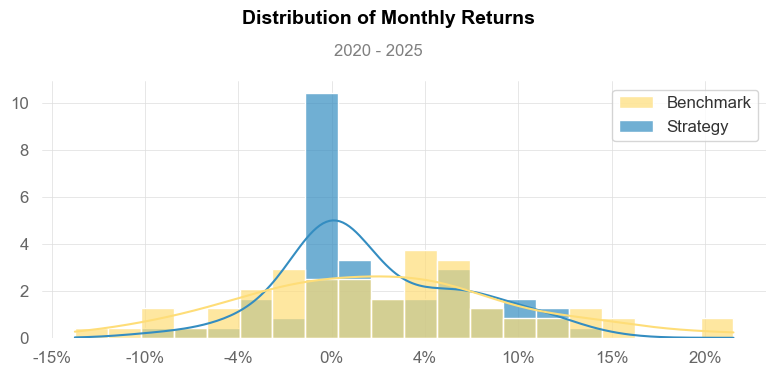

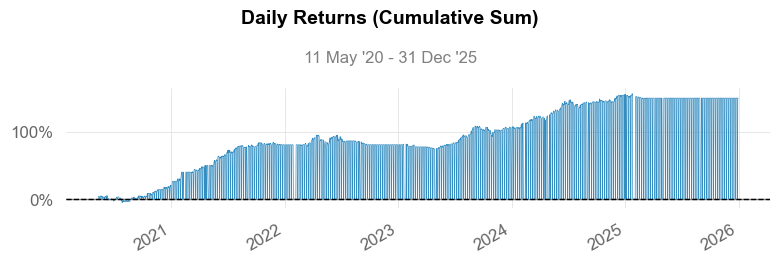

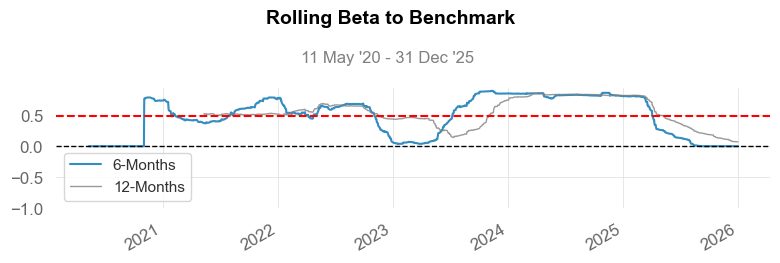

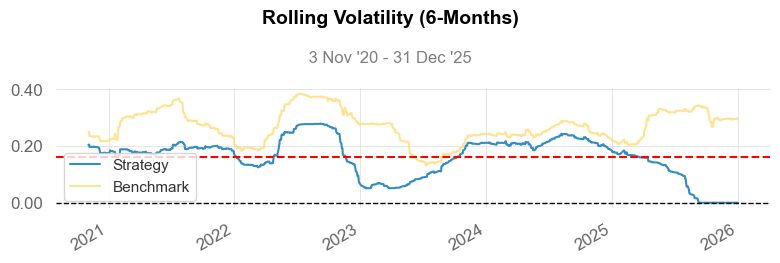

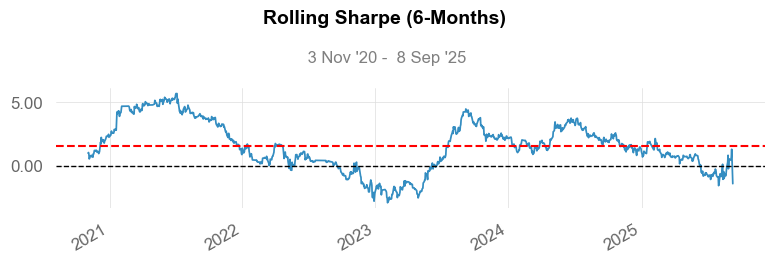

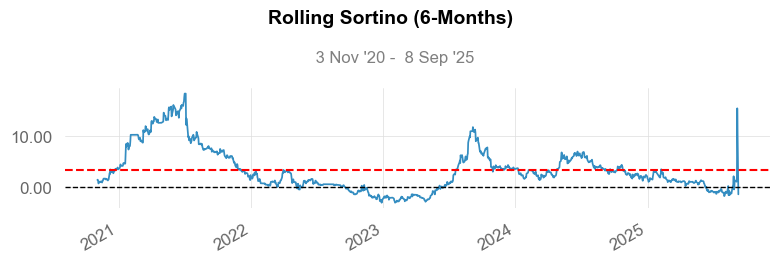

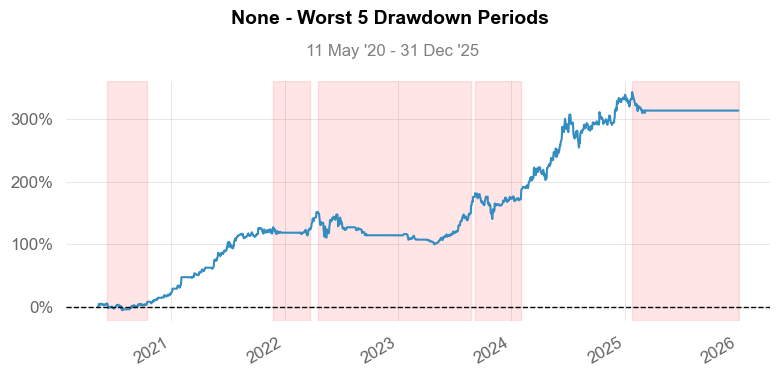

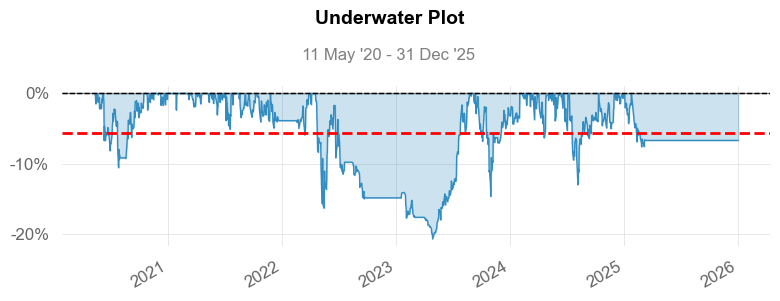

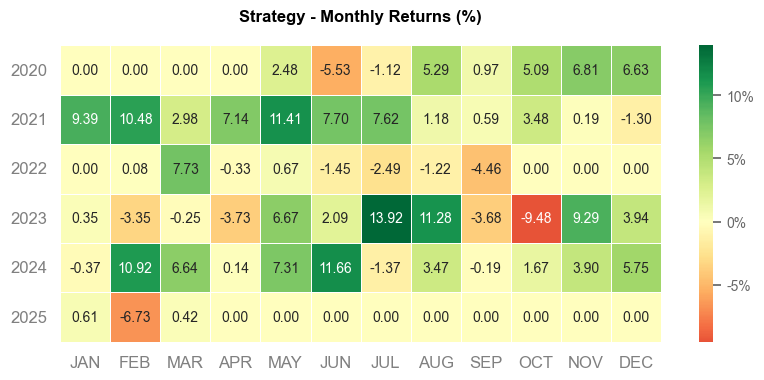

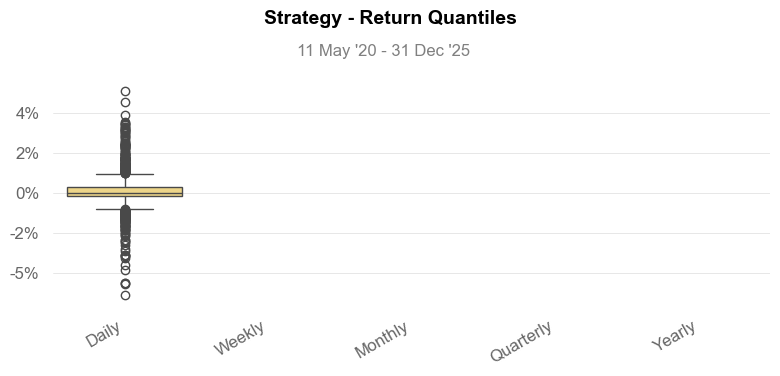

In [25]:
import vectorbt as vbt
import quantstats as qs
import pandas as pd
import numpy as np

# Cấu hình đồng bộ tần suất VectorBT về 252 phiên giao dịch/năm 
vbt.settings.returns['year_freq'] = '252 days'

# 1. MÔ PHỎNG LỆNH GIAO DỊCH VỚI STOP LOSS, TAKE PROFIT VÀ REGIME FILTER
price_test = data.loc[y_pred_all.index, 'close']
high_test = data.loc[y_pred_all.index, 'high']
low_test = data.loc[y_pred_all.index, 'low']
ma50_test = data['close'].rolling(50).mean().loc[y_pred_all.index]
ma200_test = data['close'].rolling(200).mean().loc[y_pred_all.index]

def simulate_optimized_trading(close, high, low, y_prob, entries, size_pct, sl_pct, tp_pct, hold_period, fee=0.0015, init_cash=100000000):
    n = len(close)
    sizes = pd.Series(0.0, index=close.index)
    cash = init_cash
    shares = 0.0
    active_trades = []
    
    # Kiểm tra lý do thoát lệnh
    exit_types = {'SL': 0, 'TP': 0, 'Time': 0}
    
    for i in range(n):
        current_price = close.iloc[i]
        current_high = high.iloc[i]
        current_low = low.iloc[i]
        
        # Kiểm tra thoát lệnh
        shares_to_sell = 0.0
        remaining_trades = []
        for trade in active_trades:
            if i > trade['entry_idx']:
                hit_sl = (sl_pct is not None) and (current_low <= trade['sl_price'])
                hit_tp = (tp_pct is not None) and (current_high >= trade['tp_price'])
                hit_time = (i == trade['exit_idx'])
                
                if hit_sl:
                    exit_price = trade['sl_price']
                    cash += trade['qty'] * exit_price * (1 - fee)
                    shares -= trade['qty']
                    sizes.iloc[i] -= trade['qty']
                    exit_types['SL'] += 1
                elif hit_tp:
                    exit_price = trade['tp_price']
                    cash += trade['qty'] * exit_price * (1 - fee)
                    shares -= trade['qty']
                    sizes.iloc[i] -= trade['qty']
                    exit_types['TP'] += 1
                elif hit_time:
                    exit_price = current_price
                    cash += trade['qty'] * exit_price * (1 - fee)
                    shares -= trade['qty']
                    sizes.iloc[i] -= trade['qty']
                    exit_types['Time'] += 1
                else:
                    remaining_trades.append(trade)
            else:
                remaining_trades.append(trade)
        active_trades = remaining_trades
        
        # Kiểm tra vào lệnh
        if entries.iloc[i]:
            nav = cash + shares * current_price
            order_value = nav * size_pct
            if order_value > cash:
                order_value = cash
            qty = order_value / (current_price * (1 + fee))
            if qty > 0:
                cash -= qty * current_price * (1 + fee)
                shares += qty
                sizes.iloc[i] += qty
                active_trades.append({
                    'qty': qty,
                    'entry_idx': i,
                    'exit_idx': min(i + hold_period, n - 1),
                    'tp_price': current_price * (1 + tp_pct) if tp_pct is not None else None,
                    'sl_price': current_price * (1 - sl_pct) if sl_pct is not None else None
                })
                
    if len(active_trades) > 0:
        final_price = close.iloc[-1]
        for trade in active_trades:
            cash += trade['qty'] * final_price * (1 - fee)
            shares -= trade['qty']
            sizes.iloc[-1] -= trade['qty']
            
    print(f"Thống kê số lượng lệnh đóng theo lý do: {exit_types}")
    return sizes


# 2. KHỞI TẠO CẤU HÌNH TỐI ƯU HÓA 
optimal_size = 0.35
optimal_thres = 0.54
optimal_hold = 25
optimal_tp = 0.05
optimal_sl = None

# Regime Filter Market: Chỉ mua khi giá đóng cửa nằm trên cả MA50 và MA200 (Thị trường xác nhận uptrend )
regime_filter = (price_test > ma50_test) & (price_test > ma200_test)
entries = (y_prob_all > optimal_thres) & regime_filter

print("--- THỰC THI BACKTEST VỚI CẤU HÌNH ---")
order_sizes = simulate_optimized_trading(
    price_test, high_test, low_test, y_prob_all, entries,
    size_pct=optimal_size, sl_pct=optimal_sl, tp_pct=optimal_tp, hold_period=optimal_hold
)

# Khởi tạo Portfolio trong VectorBT
portfolio_optimal = vbt.Portfolio.from_orders(
    close=price_test, 
    size=order_sizes,
    size_type='amount',
    fees=0.0015,
    freq='1D',
    init_cash=100000000
)

# In kết quả báo cáo VectorBT 
print("\n--- VECTORBT BACKTEST ---")
print(portfolio_optimal.stats())

# 3. TRỰC QUAN HÓA BẰNG QUANTSTATS
strategy_returns = portfolio_optimal.returns()
benchmark_returns = price_test.pct_change().dropna()
qs.reports.full(strategy_returns, benchmark=benchmark_returns)
